<a href="https://colab.research.google.com/github/CamilaGois/machine-learning-projeto-final/blob/main/Desafio_Final_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

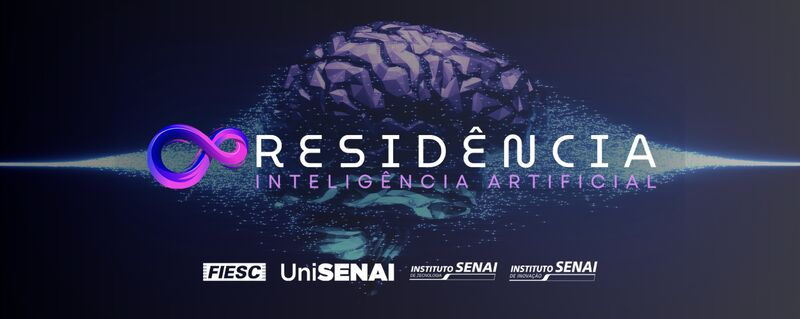

<h1><b>Pós-Graduação em Inteligência Artificial Aplicada</b></h1>



<h2>Unidade Curricular : Aprendizado de Máquina</h2>



<h2>Professor : Régis Cardoso</h2>



<h1><b>Desafio 3 <b></h1>

---

**Temática**: Modelo para indicação de graduação

**Alunos**: Ana Carolina Dutra Ramos, Camila Gois de Jesus, Guilherme Magalhães Júnior

**Data**: 26/03/2026


---

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# **1) Introdução (Contextualização do Problema)**

Este projeto consiste no desenvolvimento de um pipeline completo de Machine Learning para a recomendação de cursos de graduação, baseado no perfil e preferências de estudantes. O objetivo é aplicar o framework CRISP-DM para transformar dados brutos em um sistema preditivo funcional.

A base de dados utilizada contém informações demográficas e níveis de interesse (escala de 1 a 5) em áreas como Matemática, Programação, Biologia, Artes e Negócios. A partir desses dados, o modelo deve identificar padrões que correlacionam as preferências do aluno com a graduação mais indicada, abrangendo áreas como Engenharia, Medicina, Direito, Design, entre outras.

O escopo do trabalho engloba:

* Análise e Preparação: Limpeza de dados e tratamento de variáveis categóricas.

* Modelagem: Treinamento e comparação de algoritmos de classificação.

* MLOps: Monitoramento de experimentos e registro de métricas.

* Deploy: Publicação de uma interface funcional para consumo do modelo em ambiente real.

#**2) Análise exploratória dos dados (EDA)**

In [ ]:
# Carregando os dados

ds = pd.read_csv('/content/dataset_graduacao_indicada.csv')

In [ ]:
ds.head()

,Idade,Curso_Tecnico,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia,Graduacao_Indicada
0,45,Sim,7,1,4,2,3,5,3,1,1,5,1,Licenciatura em História
1,31,Sim,7,2,2,1,3,5,3,4,1,5,4,Direito
2,24,Sim,5,1,2,2,2,2,5,5,2,3,5,Direito
3,37,Sim,4,2,1,4,1,3,1,5,5,1,2,Administração
4,35,Sim,6,3,5,5,5,2,1,3,5,1,1,Administração


In [ ]:
ds.shape

(20000, 14)

In [ ]:
ds.describe()

,Idade,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,33.522500,4.997500,3.00070,2.989700,3.021600,2.992850,3.000100,2.988550,3.004550,2.999150,3.020200,2.989350
std,9.745068,1.412265,1.41545,1.421652,1.412386,1.414743,1.415451,1.413371,1.409868,1.414832,1.415377,1.413413
min,17.000000,3.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,25.000000,4.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,33.000000,5.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,42.000000,6.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,50.000000,7.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Idade               20000 non-null  int64 
 1   Curso_Tecnico       20000 non-null  object
 2   Anos_Para_Formar    20000 non-null  int64 
 3   Gosta_Matematica    20000 non-null  int64 
 4   Gosta_Programacao   20000 non-null  int64 
 5   Gosta_Biologia      20000 non-null  int64 
 6   Gosta_Fisica        20000 non-null  int64 
 7   Gosta_Quimica       20000 non-null  int64 
 8   Gosta_Arte_Design   20000 non-null  int64 
 9   Gosta_Comunicacao   20000 non-null  int64 
 10  Gosta_Negocios      20000 non-null  int64 
 11  Gosta_Historia      20000 non-null  int64 
 12  Gosta_Geografia     20000 non-null  int64 
 13  Graduacao_Indicada  20000 non-null  object
dtypes: int64(12), object(2)
memory usage: 2.1+ MB


In [ ]:
ds.isnull().sum()

,0
Idade,0
Curso_Tecnico,0
Anos_Para_Formar,0
Gosta_Matematica,0
Gosta_Programacao,0
Gosta_Biologia,0
Gosta_Fisica,0
Gosta_Quimica,0
Gosta_Arte_Design,0
Gosta_Comunicacao,0


In [ ]:
# Verificação dos valores das features não numéricas

ds['Curso_Tecnico'].nunique()

2

In [ ]:
ds['Curso_Tecnico'].unique()

array(['Sim', 'Não'], dtype=object)

In [ ]:
# Verificação dos valores das features não numéricas

ds['Graduacao_Indicada'].nunique()

14

In [ ]:
ds['Graduacao_Indicada'].unique()

array(['Licenciatura em História', 'Direito', 'Administração', 'Design',
       'Educação Física', 'Ciência da Computação', 'Odontologia',
       'Medicina', 'Psicologia', 'Licenciatura em Matemática',
       'Comunicação Social', 'Licenciatura em Geografia', 'Engenharia',
       'Licenciatura em Biologia'], dtype=object)

In [ ]:
# Verificar se o dataset está desbalanceado

ds['Graduacao_Indicada'].value_counts(normalize=True)

,proportion
Graduacao_Indicada,
Administração,0.23100
Direito,0.18090
Design,0.14045
Medicina,0.11930
Odontologia,0.07815
Educação Física,0.04650
Psicologia,0.04295
Ciência da Computação,0.03775
Licenciatura em Matemática,0.03570


# **3) Tratamento dos dados**

## a) Transformando feature categórica para o tipo numérico

In [ ]:
# Feature: Curso_Tecnico

ds['Curso_Tecnico'] = ds['Curso_Tecnico'].map({"Sim": 1, "Não":0})

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Idade               20000 non-null  int64 
 1   Curso_Tecnico       20000 non-null  int64 
 2   Anos_Para_Formar    20000 non-null  int64 
 3   Gosta_Matematica    20000 non-null  int64 
 4   Gosta_Programacao   20000 non-null  int64 
 5   Gosta_Biologia      20000 non-null  int64 
 6   Gosta_Fisica        20000 non-null  int64 
 7   Gosta_Quimica       20000 non-null  int64 
 8   Gosta_Arte_Design   20000 non-null  int64 
 9   Gosta_Comunicacao   20000 non-null  int64 
 10  Gosta_Negocios      20000 non-null  int64 
 11  Gosta_Historia      20000 non-null  int64 
 12  Gosta_Geografia     20000 non-null  int64 
 13  Graduacao_Indicada  20000 non-null  object
dtypes: int64(13), object(1)
memory usage: 2.1+ MB


## b) Transformando o rótulo para o tipo numérico

In [ ]:
# Rótulo: feature "Graduacao_Indicada"

le = LabelEncoder()

ds['Graduacao_Indicada'] = le.fit_transform(ds['Graduacao_Indicada'])

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Idade               20000 non-null  int64
 1   Curso_Tecnico       20000 non-null  int64
 2   Anos_Para_Formar    20000 non-null  int64
 3   Gosta_Matematica    20000 non-null  int64
 4   Gosta_Programacao   20000 non-null  int64
 5   Gosta_Biologia      20000 non-null  int64
 6   Gosta_Fisica        20000 non-null  int64
 7   Gosta_Quimica       20000 non-null  int64
 8   Gosta_Arte_Design   20000 non-null  int64
 9   Gosta_Comunicacao   20000 non-null  int64
 10  Gosta_Negocios      20000 non-null  int64
 11  Gosta_Historia      20000 non-null  int64
 12  Gosta_Geografia     20000 non-null  int64
 13  Graduacao_Indicada  20000 non-null  int64
dtypes: int64(14)
memory usage: 2.1 MB


In [ ]:
ds['Graduacao_Indicada'].nunique()

14

In [ ]:
ds['Graduacao_Indicada'].unique()

array([ 9,  4,  0,  3,  5,  1, 12, 11, 13, 10,  2,  8,  6,  7])

## c) Formatando o dataset e gerando a base de dados e o target

In [ ]:
x = ds.drop(columns = ['Graduacao_Indicada'])
y = ds['Graduacao_Indicada']

In [ ]:
x.head()

,Idade,Curso_Tecnico,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia
0,45,1,7,1,4,2,3,5,3,1,1,5,1
1,31,1,7,2,2,1,3,5,3,4,1,5,4
2,24,1,5,1,2,2,2,2,5,5,2,3,5
3,37,1,4,2,1,4,1,3,1,5,5,1,2
4,35,1,6,3,5,5,5,2,1,3,5,1,1


In [ ]:
x.shape

(20000, 13)

In [ ]:
y.head()

,Graduacao_Indicada
0,9
1,4
2,4
3,0
4,0


In [ ]:
y.shape

(20000,)

In [ ]:
# Verificando a proporção dos rótulos

y.value_counts(normalize=True)

,proportion
Graduacao_Indicada,
0,0.23100
4,0.18090
3,0.14045
11,0.11930
12,0.07815
5,0.04650
13,0.04295
1,0.03775
10,0.03570


## d) Split treino/teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
X_train.shape

(16000, 13)

In [ ]:
y_train.shape

(16000,)

In [ ]:
# Verificando a proporção dos rótulos (treino) após o Split

y_train.value_counts(normalize=True)

,proportion
Graduacao_Indicada,
0,0.231000
4,0.180938
3,0.140437
11,0.119313
12,0.078125
5,0.046500
13,0.042938
1,0.037750
10,0.035687


In [ ]:
# Verificando a proporção dos rótulos (teste) após o Split

y_test.value_counts(normalize=True)

,proportion
Graduacao_Indicada,
0,0.23100
4,0.18075
3,0.14050
11,0.11925
12,0.07825
5,0.04650
13,0.04300
1,0.03775
10,0.03575


# **4) Feature engineering**

## a) Padronização dos dados de treino e teste

In [ ]:
sc = StandardScaler()

# Treino
X_train = sc.fit_transform(X_train)

# Teste
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[ 1.07557123e+00, -1.01080841e+00, -1.40965178e+00, ...,
        -1.41145761e+00,  1.39824680e+00,  7.14887427e-01],
       [-5.23119927e-02, -1.01080841e+00,  7.09660572e-01, ...,
         1.41260488e+00,  1.39824680e+00, -1.40801510e+00],
       [ 1.07557123e+00, -1.01080841e+00, -7.03214331e-01, ...,
         5.73637694e-04,  6.92016962e-01, -1.40801510e+00],
       ...,
       [ 1.17810607e+00,  9.89307165e-01, -7.03214331e-01, ...,
         5.73637694e-04, -7.20442713e-01, -1.40801510e+00],
       [-8.72590698e-01,  9.89307165e-01, -7.03214331e-01, ...,
         7.06589261e-01,  6.92016962e-01,  7.14887427e-01],
       [-1.69286940e+00, -1.01080841e+00,  7.09660572e-01, ...,
        -7.05441985e-01, -1.42128755e-02, -1.40801510e+00]])

# **5) Treinamento do algoritmo**

## a) Definindo o algoritmo

In [ ]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(),
    "ExtraTreesClassifier": ExtraTreesClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "SVC": SVC(),
    "XGBClassifier": XGBClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "LGBMClassifier": LGBMClassifier(),
    "CatBoostClassifier": CatBoostClassifier(verbose=0)
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
for nome, modelo in modelos.items():
  scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy')
  print(f'{nome}: {scores.mean()}')

LogisticRegression: 0.73625
RandomForestClassifier: 0.9342499999999999
ExtraTreesClassifier: 0.8959374999999999
DecisionTreeClassifier: 0.9335000000000001
KNeighborsClassifier: 0.6816875
SVC: 0.8566874999999999
XGBClassifier: 0.9501250000000001
GradientBoosting: 0.9508125
HistGradientBoosting: 0.9494999999999999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001687 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465608
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.963327
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.963327
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000735 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.275116
[LightGBM] [Info] Start training from score -4.566851
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.388775
[LightGBM] [Info] Start training from score -5.026384
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.334708
[LightGBM] [Info] Start training from score -2.125485


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.566851
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.066960
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier: 0.9502499999999999
CatBoostClassifier: 0.9499375000000001


In [ ]:
for nome, modelo in modelos.items():
  scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1_weighted')
  print(f'{nome}: {scores.mean()}')

LogisticRegression: 0.7276226010839123
RandomForestClassifier: 0.9339481719669844
ExtraTreesClassifier: 0.8886562900815754
DecisionTreeClassifier: 0.9336221848554771
KNeighborsClassifier: 0.6699671198383799
SVC: 0.853773732381636
XGBClassifier: 0.9504523223767739
GradientBoosting: 0.9518313994873587
HistGradientBoosting: 0.9495543431287204
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465608
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training fro

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.963327
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.559361
[LightGBM] [Info] Start training from score -1.963327
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.275116
[LightGBM] [Info] Start training from score -4.566851
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.068639
[LightGBM] [Info] Start training from score -3.388775
[LightGBM] [Info] Start training from score -5.026384
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.334708
[LightGBM] [Info] Start training from score -2.125485


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 13
[LightGBM] [Info] Start training from score -1.465270
[LightGBM] [Info] Start training from score -3.277184
[LightGBM] [Info] Start training from score -4.566851
[LightGBM] [Info] Start training from score -1.962770
[LightGBM] [Info] Start training from score -1.709604
[LightGBM] [Info] Start training from score -3.066960
[LightGBM] [Info] Start training from score -3.386463
[LightGBM] [Info] Start training from score -5.038360
[LightGBM] [Info] Start training from score -4.242265
[LightGBM] [Info] Start training from score -3.808226
[LightGBM] [Info] Start training from score -3.332517
[LightGBM] [Info] Start training from score -2.126140


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier: 0.9500153195532125
CatBoostClassifier: 0.9505601043251378


## b) Definindo os melhores hiperparâmetros do algoritmo XGBClassifier

In [ ]:
# Primeira rodada

param_grid_XGB = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1]
}

In [ ]:
grid_XGB = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss"),
    param_grid_XGB,
    cv=cv,
    scoring="f1_weighted"
)

In [ ]:
grid_XGB.fit(X_train, y_train)
print(grid_XGB.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
# Segunda rodada

param_grid_XGB_second = {
    "n_estimators": [175, 200, 225],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.04, 0.05, 0.06]
}

In [ ]:
grid_XGB = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss"),
    param_grid_XGB_second,
    cv=cv,
    scoring="f1_weighted"
)

In [ ]:
grid_XGB.fit(X_train, y_train)
print(grid_XGB.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 175}


In [ ]:
# Terceira rodada

param_grid_XGB_third = {
    "n_estimators": [150, 165, 170, 175, 180, 185],
}

In [ ]:
grid_XGB = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss"),
    param_grid_XGB_third,
    cv=cv,
    scoring="f1_weighted"
)

In [ ]:
grid_XGB.fit(X_train, y_train)
print(grid_XGB.best_params_)

{'n_estimators': 175}


## c) Definindo os melhores hiperparâmetros do algoritmo GradientBoosting

In [ ]:
# Primeira rodada

param_grid_GB = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

In [ ]:
grid_GB = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB.fit(X_train, y_train)
print(grid_GB.best_params_)
print(grid_GB.best_score_)

{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100}
0.9540230954288486


In [ ]:
# Segunda rodada

param_grid_GB_second = {
    "n_estimators": [75, 100, 125],
    "learning_rate": [0.02, 0.03, 0.04],
    "max_depth": [4]}

In [ ]:
grid_GB = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB_second,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB.fit(X_train, y_train)
print(grid_GB.best_params_)
print(grid_GB.best_score_)

{'learning_rate': 0.04, 'max_depth': 4, 'n_estimators': 75}
0.9543671819854973


In [ ]:
# Terceira rodada

param_grid_GB_third = {
    "n_estimators": [70, 75, 80],
    "learning_rate": [0.04],
    "max_depth": [4, 5]}

In [ ]:
grid_GB_third = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB_third,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB_third.fit(X_train, y_train)
print(grid_GB_third.best_params_)
print(grid_GB_third.best_score_)

{'learning_rate': 0.04, 'max_depth': 4, 'n_estimators': 70}
0.9546592422625512


In [ ]:
# Quarta rodada

param_grid_GB_fourth = {
    "n_estimators": [60, 65, 70],
    "learning_rate": [0.04],
    "max_depth": [4]}

In [ ]:
grid_GB_fourth = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB_fourth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB_fourth.fit(X_train, y_train)
print(grid_GB_third.best_params_)
print(grid_GB_third.best_score_)

{'learning_rate': 0.04, 'max_depth': 4, 'n_estimators': 70}
0.9546592422625512


In [ ]:
# Quinta rodada

param_grid_GB_fifth = {
    "n_estimators": [70],
    "learning_rate": [0.04],
    "max_depth": [4],
    "subsample": [0.7, 0.8, 0.9],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3]
    }

In [ ]:
grid_GB_fifth = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB_fifth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB_fifth.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.04], 'max_depth': [4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 5, 10], 'n_estimators': [70],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='f1_weighted')

In [ ]:
print(grid_GB_fifth.best_params_)
print(grid_GB_fifth.best_score_)

{'learning_rate': 0.04, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 70, 'subsample': 0.8}
0.9551604673514109


In [ ]:
# Sexta rodada

param_grid_GB_sixth = {
    "n_estimators": [70],
    "learning_rate": [0.04],
    "max_depth": [4],
    "subsample": [0.8],
    "min_samples_split": [1, 2, 3],
    "min_samples_leaf": [1]
    }

In [ ]:
grid_GB_sixth = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_GB_sixth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_GB_sixth.fit(X_train, y_train)
print(grid_GB_sixth.best_params_)
print(grid_GB_sixth.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_pa

{'learning_rate': 0.04, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 70, 'subsample': 0.8}
0.9551604673514109


## d) Definindo os melhores hiperparâmetros do algoritmo LGBMClassifier

In [ ]:
# Primeira rodada

param_grid_LGBM = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
}

In [ ]:
grid_LGBM = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM.fit(X_train, y_train)
print(grid_LGBM.best_params_)
print(grid_LGBM.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
0.9542438708111712


In [ ]:
# Segunda rodada

param_grid_LGBM_second = {
    "n_estimators": [80, 100, 120],
    "learning_rate": [0.04, 0.05, 0.06],
    "max_depth": [1, 2, 3],
    "num_leaves": [7, 15, 31]
}

In [ ]:
grid_LGBM_second = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM_second,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM_second.fit(X_train, y_train)
print(grid_LGBM_second.best_params_)
print(grid_LGBM_second.best_score_)

{'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 120, 'num_leaves': 7}
0.9543520516486753


In [ ]:
# Terceira rodada

param_grid_LGBM_third = {
    "n_estimators": [110, 120, 130],
    "learning_rate": [0.04],
    "max_depth": [3],
    "num_leaves": [6, 7, 8]
}

In [ ]:
grid_LGBM_third = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM_third,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM_third.fit(X_train, y_train)
print(grid_LGBM_third.best_params_)
print(grid_LGBM_third.best_score_)

{'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 110, 'num_leaves': 7}
0.9543523549856043


In [ ]:
# Quarta rodada

param_grid_LGBM_fourth = {
    "n_estimators": [110, 115],
    "learning_rate": [0.04],
    "max_depth": [3],
    "num_leaves": [7],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

In [ ]:
grid_LGBM_fourth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM_fourth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM_fourth.fit(X_train, y_train)
print(grid_LGBM_fourth.best_params_)
print(grid_LGBM_fourth.best_score_)

{'colsample_bytree': 0.9, 'learning_rate': 0.04, 'max_depth': 3, 'min_child_samples': 30, 'n_estimators': 110, 'num_leaves': 7, 'subsample': 0.7}
0.9541969931424216


In [ ]:
# Quinta rodada

param_grid_LGBM_fifth = {
    "n_estimators": [110],
    "learning_rate": [0.04],
    "max_depth": [3],
    "num_leaves": [7],
    "min_child_samples": [25, 30, 35],
    "subsample": [0.5, 0.6, 0.7],
    "colsample_bytree": [0.9, 1.0]
}

In [ ]:
grid_LGBM_fifth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM_fifth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM_fifth.fit(X_train, y_train)
print(grid_LGBM_fifth.best_params_)
print(grid_LGBM_fifth.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.04, 'max_depth': 3, 'min_child_samples': 25, 'n_estimators': 110, 'num_leaves': 7, 'subsample': 0.5}
0.9544284459174884


In [ ]:
# Sexta rodada

param_grid_LGBM_sixth = {
    "n_estimators": [110],
    "learning_rate": [0.04],
    "max_depth": [3],
    "num_leaves": [7],
    "min_child_samples": [25],
    "subsample": [0.1, 0.2, 0.3, 0.4, 0.5],
    "colsample_bytree": [1.0, 1.1, 1.2, 1.4]
}

In [ ]:
grid_LGBM_sixth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_LGBM_sixth,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

In [ ]:
grid_LGBM_sixth.fit(X_train, y_train)
print(grid_LGBM_sixth.best_params_)
print(grid_LGBM_sixth.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
75 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/engine.py",

{'colsample_bytree': 1.0, 'learning_rate': 0.04, 'max_depth': 3, 'min_child_samples': 25, 'n_estimators': 110, 'num_leaves': 7, 'subsample': 0.1}
0.9544284459174884


## e) Escolhendo o melhor modelo para este problema

In [ ]:
# Modelo com os melhores hiperparâmetros

modelos = {
    "XGBClassifier": XGBClassifier(learning_rate= 0.05, max_depth=3,
                                   n_estimators=175, eval_metric='mlogloss'),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=70,
                                                   learning_rate=0.04, max_depth=4,
                                                   subsample=0.8, min_samples_split=2,
                                                   min_samples_leaf=1),
    "LGBMClassifier": LGBMClassifier(n_estimators=110, learning_rate=0.04,
                                     max_depth=4, num_leaves=7, min_child_samples=25,
                                     subsample=0.1, colsample_bytree=1.0),
}

In [ ]:
for nome, modelo in modelos.items():
  scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy')
  print(f'{nome}: {scores.mean()}')

XGBClassifier: 0.951375
GradientBoosting: 0.9506249999999999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier: 0.9510625000000001


In [ ]:
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1_weighted')
    print(f'{nome} - F1-weighted: {scores.mean():.4f}')

XGBClassifier - F1-weighted: 0.9545
GradientBoosting - F1-weighted: 0.9539


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier - F1-weighted: 0.9550


In [ ]:
# Nova rodada de avalaição para desempatar os algoritmos

for nome, modelo in modelos.items():
    print(f'\n{nome}')
    for metric in ["accuracy", "f1_weighted", "f1_macro", "balanced_accuracy"]:
        scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=metric)
        print(f'  {metric}: {scores.mean():.4f}')


XGBClassifier
  accuracy: 0.9514
  f1_weighted: 0.9545
  f1_macro: 0.8502
  balanced_accuracy: 0.8699

GradientBoosting
  accuracy: 0.9512
  f1_weighted: 0.9546
  f1_macro: 0.8528
  balanced_accuracy: 0.8713

LGBMClassifier


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  accuracy: 0.9511


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  f1_weighted: 0.9550


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  f1_macro: 0.8509


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  balanced_accuracy: 0.8724


## f) Ajustes para melhorar os resultados com o melhor modelo (LGBMClassifier)

In [ ]:
# Transformando numpy em DF

X_train = pd.DataFrame(X_train, columns=x.columns, index=y_train.index)

In [ ]:
model_base = LGBMClassifier(
    n_estimators=110,
    learning_rate=0.04,
    max_depth=4,
    num_leaves=7,
    min_child_samples=25,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

In [ ]:
# Smote

pipeline_smote = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_base)
])

In [ ]:
modelos = {
    "Base": model_base,
    "SMOTE": pipeline_smote
}

for nome, modelo in modelos.items():
    print(f"\n{nome}")

    for metric in ["accuracy", "f1_weighted", "f1_macro", "balanced_accuracy"]:
        scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=metric)
        print(f"{metric}: {scores.mean():.4f}")


Base
accuracy: 0.9511
f1_weighted: 0.9550
f1_macro: 0.8509
balanced_accuracy: 0.8724

SMOTE
accuracy: 0.9504
f1_weighted: 0.9599
f1_macro: 0.8447
balanced_accuracy: 0.8761


In [ ]:
# Class weight

scores = {
    "accuracy": [],
    "f1_weighted": [],
    "f1_macro": [],
    "balanced_accuracy": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    weights = compute_sample_weight(class_weight='balanced', y=y_tr)

    model = LGBMClassifier(
        n_estimators=110,
        learning_rate=0.04,
        max_depth=4,
        num_leaves=7,
        min_child_samples=25,
        subsample=0.1,
        colsample_bytree=1.0,
        verbose=-1
    )

    model.fit(X_tr, y_tr, sample_weight=weights)

    y_pred = model.predict(X_val)

    scores["accuracy"].append(accuracy_score(y_val, y_pred))
    scores["f1_weighted"].append(f1_score(y_val, y_pred, average="weighted"))
    scores["f1_macro"].append(f1_score(y_val, y_pred, average="macro"))
    scores["balanced_accuracy"].append(balanced_accuracy_score(y_val, y_pred))

for metric, values in scores.items():
    print(f"{metric}: {np.mean(values):.4f}")

accuracy: 0.9506
f1_weighted: 0.9621
f1_macro: 0.8505
balanced_accuracy: 0.8824


## g) Treinando modelo final

In [ ]:
 model_final = LGBMClassifier(
        n_estimators=110,
        learning_rate=0.04,
        max_depth=4,
        num_leaves=7,
        min_child_samples=25,
        subsample=0.1,
        colsample_bytree=1.0,
        verbose=-1
    )

In [ ]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_final.fit(X_train, y_train, sample_weight=weights)


LGBMClassifier(learning_rate=0.04, max_depth=4, min_child_samples=25,
               n_estimators=110, num_leaves=7, subsample=0.1, verbose=-1)

## h) Teste final (conjunto de teste)

In [ ]:
y_pred = model_final.predict(X_test)

print('Accuracy = ', accuracy_score(y_test, y_pred))
print("F1-weighted = ", f1_score(y_test, y_pred, average='weighted'))
print("F1-macro = ", f1_score(y_test, y_pred, average="macro"))
print("Balanced_accuracy = ", balanced_accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy =  0.94575
F1-weighted =  0.959280018009361
F1-macro =  0.8398556884133531
Balanced_accuracy =  0.8671957065422399


## i) Avaliação do resultado

In [ ]:
confusion_matrix(y_test, y_pred)

array([[911,   0,   5,   0,   0,   0,   0,   7,   0,   1,   0,   0,   0,
          0],
       [  0, 135,   5,   0,   0,   0,   0,   9,   2,   0,   0,   0,   0,
          0],
       [  0,   1,  29,   0,   0,   0,   0,   7,   4,   1,   0,   0,   0,
          0],
       [  0,   0,   7, 547,   0,   0,   0,   7,   1,   0,   0,   0,   0,
          0],
       [  0,   0,  14,   0, 705,   0,   0,   3,   1,   0,   0,   0,   0,
          0],
       [  0,   0,   9,   0,   0, 167,   0,   8,   2,   0,   0,   0,   0,
          0],
       [  0,   0,   1,   0,   0,   0, 120,  10,   2,   2,   0,   0,   0,
          0],
       [  0,   0,   6,   0,   0,   0,   0,  15,   4,   1,   0,   0,   0,
          0],
       [  0,   0,   7,   0,   0,   0,   0,   5,  43,   2,   0,   0,   0,
          0],
       [  0,   0,   9,   0,   0,   0,   0,   6,   1,  73,   0,   0,   0,
          0],
       [  0,   0,   7,   0,   0,   0,   0,   7,   2,   0, 127,   0,   0,
          0],
       [  0,   0,   6,   0,   0,   0,   0, 

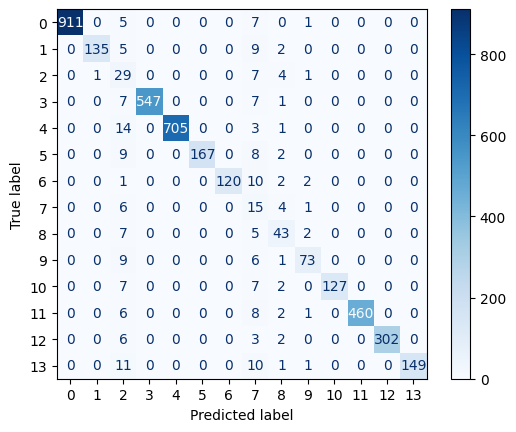

In [ ]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       924
           1       0.99      0.89      0.94       151
           2       0.24      0.69      0.35        42
           3       1.00      0.97      0.99       562
           4       1.00      0.98      0.99       723
           5       1.00      0.90      0.95       186
           6       1.00      0.89      0.94       135
           7       0.14      0.58      0.23        26
           8       0.64      0.75      0.69        57
           9       0.89      0.82      0.85        89
          10       1.00      0.89      0.94       143
          11       1.00      0.96      0.98       477
          12       1.00      0.96      0.98       313
          13       1.00      0.87      0.93       172

    accuracy                           0.95      4000
   macro avg       0.85      0.87      0.84      4000
weighted avg       0.98      0.95      0.96      4000



## j) Nova rodada de tuning focada em classes raras

In [ ]:
# Primeira rodada

param_grid_new_LGBM = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
}

grid_new_LGBM = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM.fit(X_train, y_train)
print(grid_new_LGBM.best_params_)
print(grid_new_LGBM.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.8652785523302043


In [ ]:
# Segundaa rodada

param_grid_new_LGBM_second = {
    "n_estimators": [95, 100, 115],
    "learning_rate": [0.09, 0.1, 0.11],
    "max_depth": [5, 6, 7],
}

grid_new_LGBM_second = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM_second,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM_second.fit(X_train, y_train)
print(grid_new_LGBM_second.best_params_)
print(grid_new_LGBM_second.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.8652785523302043


In [ ]:
# Terceira rodada

param_grid_new_LGBM_third = {
    "n_estimators": [100, 105, 110],
    "learning_rate": [0.1],
    "max_depth": [5],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [10, 20, 30]
}

grid_new_LGBM_third = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM_third,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM_third.fit(X_train, y_train)
print(grid_new_LGBM_third.best_params_)
print(grid_new_LGBM_third.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
0.8652785523302043


In [ ]:
# Quarta rodada

param_grid_new_LGBM_fourth = {
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [5],
    "num_leaves": [28, 31, 34],
    "min_child_samples": [18, 20, 22]
}

grid_new_LGBM_fourth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM_fourth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM_fourth.fit(X_train, y_train)
print(grid_new_LGBM_fourth.best_params_)
print(grid_new_LGBM_fourth.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
0.8652785523302043


In [ ]:
# Quinta rodada

param_grid_new_LGBM_fifth = {
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [5],
    "num_leaves": [31],
    "min_child_samples": [20],
    "subsample": [0.2, 0.3, 0.4],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

grid_new_LGBM_fifth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM_fifth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM_fifth.fit(X_train, y_train)
print(grid_new_LGBM_fifth.best_params_)
print(grid_new_LGBM_fifth.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.2}
0.8652785523302043


In [ ]:
# Quinta rodada

param_grid_new_LGBM_sixth = {
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [5],
    "num_leaves": [31],
    "min_child_samples": [20],
    "subsample": [0.1, 0.2],
    "colsample_bytree": [1.0]
}

grid_new_LGBM_sixth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new_LGBM_sixth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new_LGBM_sixth.fit(X_train, y_train)
print(grid_new_LGBM_sixth.best_params_)
print(grid_new_LGBM_sixth.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.1}
0.8652785523302043


In [ ]:
# Smote

model_base_2 = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

In [ ]:
pipeline_smote = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_base_2)
])

In [ ]:
modelos = {
    "Base": model_base_2,
    "SMOTE": pipeline_smote
}

for nome, modelo in modelos.items():
    print(f"\n{nome}")

    for metric in ["accuracy", "f1_weighted", "f1_macro", "balanced_accuracy"]:
        scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=metric)
        print(f"{metric}: {scores.mean():.4f}")


Base
accuracy: 0.9507
f1_weighted: 0.9507
f1_macro: 0.8653
balanced_accuracy: 0.8634

SMOTE
accuracy: 0.9508
f1_weighted: 0.9526
f1_macro: 0.8563
balanced_accuracy: 0.8685


In [ ]:
# Class weight

scores = {
    "accuracy": [],
    "f1_weighted": [],
    "f1_macro": [],
    "balanced_accuracy": []
}

for train_idx, val_idx in cv.split(X_train, y_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    weights = compute_sample_weight(class_weight='balanced', y=y_tr)

    model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

    model.fit(X_tr, y_tr, sample_weight=weights)

    y_pred = model.predict(X_val)

    scores["accuracy"].append(accuracy_score(y_val, y_pred))
    scores["f1_weighted"].append(f1_score(y_val, y_pred, average="weighted"))
    scores["f1_macro"].append(f1_score(y_val, y_pred, average="macro"))
    scores["balanced_accuracy"].append(balanced_accuracy_score(y_val, y_pred))

for metric, values in scores.items():
    print(f"{metric}: {np.mean(values):.4f}")

accuracy: 0.9498
f1_weighted: 0.9526
f1_macro: 0.8473
balanced_accuracy: 0.8644


## k) Nova etapa de feature engineering

In [ ]:
# Dataset pré "split"

ds.head()

,Idade,Curso_Tecnico,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,Gosta_Negocios,Gosta_Historia,Gosta_Geografia,Graduacao_Indicada
0,45,1,7,1,4,2,3,5,3,1,1,5,1,9
1,31,1,7,2,2,1,3,5,3,4,1,5,4,4
2,24,1,5,1,2,2,2,2,5,5,2,3,5,4
3,37,1,4,2,1,4,1,3,1,5,5,1,2,0
4,35,1,6,3,5,5,5,2,1,3,5,1,1,0


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Idade               20000 non-null  int64
 1   Curso_Tecnico       20000 non-null  int64
 2   Anos_Para_Formar    20000 non-null  int64
 3   Gosta_Matematica    20000 non-null  int64
 4   Gosta_Programacao   20000 non-null  int64
 5   Gosta_Biologia      20000 non-null  int64
 6   Gosta_Fisica        20000 non-null  int64
 7   Gosta_Quimica       20000 non-null  int64
 8   Gosta_Arte_Design   20000 non-null  int64
 9   Gosta_Comunicacao   20000 non-null  int64
 10  Gosta_Negocios      20000 non-null  int64
 11  Gosta_Historia      20000 non-null  int64
 12  Gosta_Geografia     20000 non-null  int64
 13  Graduacao_Indicada  20000 non-null  int64
dtypes: int64(14)
memory usage: 2.1 MB


In [ ]:
ds.shape

(20000, 14)

In [ ]:
# Lista das colunas de interesse
colunas_interesse = [
    "Gosta_Matematica",
    "Gosta_Programacao",
    "Gosta_Biologia",
    "Gosta_Fisica",
    "Gosta_Quimica",
    "Gosta_Arte_Design",
    "Gosta_Comunicacao",
    "Gosta_Negocios",
    "Gosta_Historia",
    "Gosta_Geografia"
]

# a) Perfis agregados
ds["perfil_STEM"] = (
    ds["Gosta_Matematica"] +
    ds["Gosta_Programacao"] +
    ds["Gosta_Fisica"] +
    ds["Gosta_Quimica"]
)

ds["perfil_Humanas"] = (
    ds["Gosta_Historia"] +
    ds["Gosta_Geografia"] +
    ds["Gosta_Comunicacao"]
)

ds["perfil_Biologicas"] = (
    ds["Gosta_Biologia"] +
    ds["Gosta_Quimica"]
)

ds["perfil_Criativo"] = ds["Gosta_Arte_Design"]

ds["perfil_Negocios"] = (
    ds["Gosta_Negocios"] +
    ds["Gosta_Comunicacao"]
)

# b) Diferenças entre perfis
ds["dif_STEM_vs_Humanas"] = ds["perfil_STEM"] - ds["perfil_Humanas"]
ds["dif_STEM_vs_Biologicas"] = ds["perfil_STEM"] - ds["perfil_Biologicas"]
ds["dif_Humanas_vs_Negocios"] = ds["perfil_Humanas"] - ds["perfil_Negocios"]
ds["dif_Criativo_vs_STEM"] = ds["perfil_Criativo"] - ds["perfil_STEM"]

# c) Estatísticas dos interesses
ds["media_interesses"] = ds[colunas_interesse].mean(axis=1)
ds["variancia_interesses"] = ds[colunas_interesse].var(axis=1)
ds["max_interesse"] = ds[colunas_interesse].max(axis=1)
ds["min_interesse"] = ds[colunas_interesse].min(axis=1)
ds["amplitude_interesses"] = ds["max_interesse"] - ds["min_interesse"]

# d) Quantidade de interesses altos e baixos
ds["qtd_interesses_altos"] = (ds[colunas_interesse] >= 4).sum(axis=1)
ds["qtd_interesses_baixos"] = (ds[colunas_interesse] <= 2).sum(axis=1)

# e) Interações com Curso_Tecnico
ds["tecnico_x_STEM"] = ds["Curso_Tecnico"] * ds["perfil_STEM"]
ds["tecnico_x_Humanas"] = ds["Curso_Tecnico"] * ds["perfil_Humanas"]
ds["tecnico_x_Biologicas"] = ds["Curso_Tecnico"] * ds["perfil_Biologicas"]

# f) Interações com idade e tempo
ds["idade_x_STEM"] = ds["Idade"] * ds["perfil_STEM"]
ds["idade_x_Humanas"] = ds["Idade"] * ds["perfil_Humanas"]
ds["tempo_x_STEM"] = ds["Anos_Para_Formar"] * ds["perfil_STEM"]
ds["tempo_x_Humanas"] = ds["Anos_Para_Formar"] * ds["perfil_Humanas"]

# g) Área preferida (nome da coluna com maior valor)
ds["area_preferida"] = ds[colunas_interesse].idxmax(axis=1)

# Converter area_preferida para número
le_area = LabelEncoder()
ds["area_preferida"] = le_area.fit_transform(ds["area_preferida"])

# Verificar resultado
print(ds.shape)
ds.head()

(20000, 38)


,Idade,Curso_Tecnico,Anos_Para_Formar,Gosta_Matematica,Gosta_Programacao,Gosta_Biologia,Gosta_Fisica,Gosta_Quimica,Gosta_Arte_Design,Gosta_Comunicacao,...,qtd_interesses_altos,qtd_interesses_baixos,tecnico_x_STEM,tecnico_x_Humanas,tecnico_x_Biologicas,idade_x_STEM,idade_x_Humanas,tempo_x_STEM,tempo_x_Humanas,area_preferida
0,45,1,7,1,4,2,3,5,3,1,...,3,5,13,7,7,585,315,91,49,9
1,31,1,7,2,2,1,3,5,3,4,...,4,4,12,13,6,372,403,84,91,9
2,24,1,5,1,2,2,2,2,5,5,...,3,6,7,13,4,168,312,35,65,0
3,37,1,4,2,1,4,1,3,1,5,...,3,6,7,8,7,259,296,28,32,2
4,35,1,6,3,5,5,5,2,1,3,...,4,4,15,5,7,525,175,90,30,8


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    20000 non-null  int64  
 1   Curso_Tecnico            20000 non-null  int64  
 2   Anos_Para_Formar         20000 non-null  int64  
 3   Gosta_Matematica         20000 non-null  int64  
 4   Gosta_Programacao        20000 non-null  int64  
 5   Gosta_Biologia           20000 non-null  int64  
 6   Gosta_Fisica             20000 non-null  int64  
 7   Gosta_Quimica            20000 non-null  int64  
 8   Gosta_Arte_Design        20000 non-null  int64  
 9   Gosta_Comunicacao        20000 non-null  int64  
 10  Gosta_Negocios           20000 non-null  int64  
 11  Gosta_Historia           20000 non-null  int64  
 12  Gosta_Geografia          20000 non-null  int64  
 13  Graduacao_Indicada       20000 non-null  int64  
 14  perfil_STEM           

In [ ]:
ds['area_preferida'].head(10)

,area_preferida
0,9
1,9
2,0
3,2
4,8
5,9
6,3
7,8
8,0
9,6


In [ ]:
# Transformando a feature "area_preferiada"

dummies = pd.get_dummies(ds["area_preferida"], prefix="area")
ds = pd.concat([ds, dummies], axis=1)
ds.drop(columns=["area_preferida"], inplace=True)

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    20000 non-null  int64  
 1   Curso_Tecnico            20000 non-null  int64  
 2   Anos_Para_Formar         20000 non-null  int64  
 3   Gosta_Matematica         20000 non-null  int64  
 4   Gosta_Programacao        20000 non-null  int64  
 5   Gosta_Biologia           20000 non-null  int64  
 6   Gosta_Fisica             20000 non-null  int64  
 7   Gosta_Quimica            20000 non-null  int64  
 8   Gosta_Arte_Design        20000 non-null  int64  
 9   Gosta_Comunicacao        20000 non-null  int64  
 10  Gosta_Negocios           20000 non-null  int64  
 11  Gosta_Historia           20000 non-null  int64  
 12  Gosta_Geografia          20000 non-null  int64  
 13  Graduacao_Indicada       20000 non-null  int64  
 14  perfil_STEM           

In [ ]:
ds['area_0'].head(10)

,area_0
0,False
1,False
2,True
3,False
4,False
5,False
6,False
7,False
8,True
9,False


In [ ]:
ds[dummies.columns] = ds[dummies.columns].astype(int)

In [ ]:
ds['area_0'].head(10)

,area_0
0,0
1,0
2,1
3,0
4,0
5,0
6,0
7,0
8,1
9,0


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    20000 non-null  int64  
 1   Curso_Tecnico            20000 non-null  int64  
 2   Anos_Para_Formar         20000 non-null  int64  
 3   Gosta_Matematica         20000 non-null  int64  
 4   Gosta_Programacao        20000 non-null  int64  
 5   Gosta_Biologia           20000 non-null  int64  
 6   Gosta_Fisica             20000 non-null  int64  
 7   Gosta_Quimica            20000 non-null  int64  
 8   Gosta_Arte_Design        20000 non-null  int64  
 9   Gosta_Comunicacao        20000 non-null  int64  
 10  Gosta_Negocios           20000 non-null  int64  
 11  Gosta_Historia           20000 non-null  int64  
 12  Gosta_Geografia          20000 non-null  int64  
 13  Graduacao_Indicada       20000 non-null  int64  
 14  perfil_STEM           

In [ ]:
# Formatando o novo dataset e gerando a nova base de dados

x_new = ds.drop(columns = ['Graduacao_Indicada'])
y_new = ds['Graduacao_Indicada']

In [ ]:
x_new.shape

(20000, 46)

In [ ]:
x_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    20000 non-null  int64  
 1   Curso_Tecnico            20000 non-null  int64  
 2   Anos_Para_Formar         20000 non-null  int64  
 3   Gosta_Matematica         20000 non-null  int64  
 4   Gosta_Programacao        20000 non-null  int64  
 5   Gosta_Biologia           20000 non-null  int64  
 6   Gosta_Fisica             20000 non-null  int64  
 7   Gosta_Quimica            20000 non-null  int64  
 8   Gosta_Arte_Design        20000 non-null  int64  
 9   Gosta_Comunicacao        20000 non-null  int64  
 10  Gosta_Negocios           20000 non-null  int64  
 11  Gosta_Historia           20000 non-null  int64  
 12  Gosta_Geografia          20000 non-null  int64  
 13  perfil_STEM              20000 non-null  int64  
 14  perfil_Humanas        

In [ ]:
y_new.shape

(20000,)

In [ ]:
# Split treino/teste

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(x_new, y_new, test_size=0.2, stratify=y, random_state=42)

In [ ]:
y_new_train.value_counts(normalize=True)

,proportion
Graduacao_Indicada,
0,0.231000
4,0.180938
3,0.140437
11,0.119313
12,0.078125
5,0.046500
13,0.042938
1,0.037750
10,0.035687


In [ ]:
y_new_test.value_counts(normalize=True)

,proportion
Graduacao_Indicada,
0,0.23100
4,0.18075
3,0.14050
11,0.11925
12,0.07825
5,0.04650
13,0.04300
1,0.03775
10,0.03575


In [ ]:
# Nova sequência de tuning com o novo dataset

# Primeira rodada
param_grid_new2_LGBM = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5],
}

grid_new2_LGBM = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM.fit(X_new_train, y_new_train)
print(grid_new2_LGBM.best_params_)
print(grid_new2_LGBM.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
0.8601682633910475


In [ ]:
# Segunda rodada
param_grid_new2_LGBM_second = {
    "n_estimators": [275, 300, 325],
    "learning_rate": [0.09, 0.1, 0.11],
    "max_depth": [5, 6],
}

grid_new2_LGBM_second = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM_second,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM_second.fit(X_new_train, y_new_train)
print(grid_new2_LGBM_second.best_params_)
print(grid_new2_LGBM_second.best_score_)

{'learning_rate': 0.11, 'max_depth': 6, 'n_estimators': 300}
0.8640601675054299


In [ ]:
#Terceira rodada
param_grid_new2_LGBM_third = {
    "n_estimators": [300],
    "learning_rate": [0.11, 0.12, 0.15],
    "max_depth": [6, 7, 8],
}

grid_new2_LGBM_third = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM_third,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM_third.fit(X_new_train, y_new_train)
print(grid_new2_LGBM_third.best_params_)
print(grid_new2_LGBM_third.best_score_)

{'learning_rate': 0.11, 'max_depth': 6, 'n_estimators': 300}
0.8640601675054299


In [ ]:
# Quarta rodada
param_grid_new2_LGBM_fourth = {
    "n_estimators": [300],
    "learning_rate": [0.11],
    "max_depth": [6],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [10, 20, 30]
}

grid_new2_LGBM_fourth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM_fourth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM_fourth.fit(X_new_train, y_new_train)
print(grid_new2_LGBM_fourth.best_params_)
print(grid_new2_LGBM_fourth.best_score_)

{'learning_rate': 0.11, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
0.8640601675054299


In [ ]:
# Quinta rodada
param_grid_new2_LGBM_fifth = {
    "n_estimators": [300],
    "learning_rate": [0.11],
    "max_depth": [6],
    "num_leaves": [31, 32, 33],
    "min_child_samples": [18, 20, 22]
}

grid_new2_LGBM_fifth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM_fifth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM_fifth.fit(X_new_train, y_new_train)
print(grid_new2_LGBM_fifth.best_params_)
print(grid_new2_LGBM_fifth.best_score_)

{'learning_rate': 0.11, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
0.8640601675054299


In [ ]:
# Quinta rodada
param_grid_new2_LGBM_sixth = {
    "n_estimators": [300],
    "learning_rate": [0.11],
    "max_depth": [6],
    "num_leaves": [31],
    "min_child_samples": [20],
    "subsample": [0.1, 0.2, 0.3],
    "colsample_bytree": [0.9, 1.0]
}

grid_new2_LGBM_sixth = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    param_grid_new2_LGBM_sixth,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_new2_LGBM_sixth.fit(X_new_train, y_new_train)
print(grid_new2_LGBM_sixth.best_params_)
print(grid_new2_LGBM_sixth.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.11, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.1}
0.8640601675054299


In [ ]:
# Smote

model_base_3 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.11,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

In [ ]:
pipeline_smote = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", model_base_3)
])

In [ ]:
modelos = {
    "Base": model_base_3,
    "SMOTE": pipeline_smote
}

for nome, modelo in modelos.items():
    print(f"\n{nome}")

    for metric in ["accuracy", "f1_weighted", "f1_macro", "balanced_accuracy"]:
        scores = cross_val_score(modelo, X_new_train, y_new_train, cv=cv, scoring=metric)
        print(f"{metric}: {scores.mean():.4f}")


Base
accuracy: 0.9505
f1_weighted: 0.9506
f1_macro: 0.8641
balanced_accuracy: 0.8638

SMOTE
accuracy: 0.9465
f1_weighted: 0.9481
f1_macro: 0.8416
balanced_accuracy: 0.8510


In [ ]:
# Class weight

scores = {
    "accuracy": [],
    "f1_weighted": [],
    "f1_macro": [],
    "balanced_accuracy": []
}

for train_idx, val_idx in cv.split(X_new_train, y_new_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    weights = compute_sample_weight(class_weight='balanced', y=y_tr)

    model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.11,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

    model.fit(X_tr, y_tr, sample_weight=weights)

    y_pred = model.predict(X_val)

    scores["accuracy"].append(accuracy_score(y_val, y_pred))
    scores["f1_weighted"].append(f1_score(y_val, y_pred, average="weighted"))
    scores["f1_macro"].append(f1_score(y_val, y_pred, average="macro"))
    scores["balanced_accuracy"].append(balanced_accuracy_score(y_val, y_pred))

for metric, values in scores.items():
    print(f"{metric}: {np.mean(values):.4f}")

accuracy: 0.9501
f1_weighted: 0.9508
f1_macro: 0.8560
balanced_accuracy: 0.8614


## k) Treinamento do novo modelo final

In [ ]:
model_final_2 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.11,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.1,
    colsample_bytree=1.0,
    verbose=-1
)

In [ ]:
X_new_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 1527 to 6914
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    16000 non-null  int64  
 1   Curso_Tecnico            16000 non-null  int64  
 2   Anos_Para_Formar         16000 non-null  int64  
 3   Gosta_Matematica         16000 non-null  int64  
 4   Gosta_Programacao        16000 non-null  int64  
 5   Gosta_Biologia           16000 non-null  int64  
 6   Gosta_Fisica             16000 non-null  int64  
 7   Gosta_Quimica            16000 non-null  int64  
 8   Gosta_Arte_Design        16000 non-null  int64  
 9   Gosta_Comunicacao        16000 non-null  int64  
 10  Gosta_Negocios           16000 non-null  int64  
 11  Gosta_Historia           16000 non-null  int64  
 12  Gosta_Geografia          16000 non-null  int64  
 13  perfil_STEM              16000 non-null  int64  
 14  perfil_Humanas           

In [ ]:
weights = compute_sample_weight(class_weight='balanced', y=y_new_train)
model_final_2.fit(X_new_train, y_new_train, sample_weight=weights)

LGBMClassifier(learning_rate=0.11, max_depth=6, n_estimators=300, subsample=0.1,
               verbose=-1)

In [ ]:
y_new_pred = model_final_2.predict(X_new_test)

print('Accuracy = ', accuracy_score(y_new_test, y_new_pred))
print("F1-weighted = ", f1_score(y_new_test, y_new_pred, average='weighted'))
print("F1-macro = ", f1_score(y_new_test, y_new_pred, average="macro"))
print("Balanced_accuracy = ", balanced_accuracy_score(y_new_test, y_new_pred))

Accuracy =  0.9455
F1-weighted =  0.9472376514135226
F1-macro =  0.8439629093509172
Balanced_accuracy =  0.8531150488680769
